# One deep network, two backends

pyhgf implements the same vectorised deep predictive coding network twice:

1. **JAX** (`pyhgf.model.DeepNetwork`): every sweep is a pure function staged
   and compiled by XLA. This is the backend the deep learning notebooks use,
   and the one the mixed pipelines of the
   [transformer notebook](./0.8-Transformers.ipynb) compile into a single
   program per training step.
2. **Rust** (`pyhgf.rshgf.DeepNetwork`): a native engine over the same update
   equations, executing eagerly with one matrix product per layer and no
   compilation step.

Both classes expose the same builder surface (layers are declared bottom
first with `add_layer`) and the same three entry points:

- `predict`: a batched, read-only forward pass returning the output layer's
  expected mean;
- `fit`: sequential filtering, one prediction and update sweep per sample,
  where the precisions adapt from one sample to the next (the natural mode
  for a time series);
- `batch_update`: one batch-synchronous learning step, where every sample is
  processed from the same beliefs and the per-sample weight gradients and
  precision changes are averaged and applied once. This is the learning mode
  of the transformer pipeline.

The two backends implement the same computation: the forward pass, the
sequential filtering trajectory, and the batch-synchronous weight updates
agree to floating point tolerance (asserted in
`tests/test_rs_deepnetwork.py`, and re-checked below). This notebook measures
what differs: execution time and memory. A third learner joins the
comparison as the conventional reference point: a multilayer perceptron of
the same shape trained by **backpropagation** (Equinox and optax), so the
predictive coding learners can be read against the standard deep learning
recipe.

One configuration note before comparing anything. The Rust engine computes
in `float32`, matching JAX's default dtype, so all three learners do the
same arithmetic out of the box and the measurements isolate execution, not
precision. Two cargo features adjust the engine when a different trade-off
is needed: `f64` switches the vectorised backend to `float64` (for
bit-level parity work against JAX under `jax_enable_x64`, at twice the
memory traffic), and `blas` routes the matrix products through a linked
BLAS, which pays off at wide layers and large batches. This notebook
benchmarks the default build: `float32` through the pure-Rust matrix
kernels.

In [1]:
import dataclasses
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
from jax import random

from pyhgf.model import DeepNetwork as JaxDeepNetwork
from pyhgf.rshgf import DeepNetwork as RsDeepNetwork

plt.rcParams["figure.constrained_layout.use"] = True

## 1. Matched pairs

`build_pair` constructs the same architecture on both backends and copies one
set of weights into both, so any output difference is a backend difference,
not an initialisation difference. Sizes are given bottom (output) first, as
`add_layer` declares them. The running example is the transformer's
feed-forward part, a `64 -> 128 -> 64` network: input layer of 64 nodes,
hidden layer of 128, output layer of 64.

Every layer is built with `volatility_parent=False`: the nodes carry no
volatility level, matching the pinned-confidence configuration the
[transformer notebook](./0.8-Transformers.ipynb) uses for its learning parts
(where the volatility levels are frozen by construction). This keeps the
benchmark representative of the deep-learning use of the toolbox; with the
builder default (`volatility_parent=True`), every sweep additionally runs
the volatility-level posterior, an elementwise pass heavy in exponentials
whose cost depends on the volatility scheme.


In [2]:
def build_pair(sizes, output_kind="volatile"):
    """A Rust and a JAX network with identical topology and weights.

    ``sizes`` are layer sizes bottom (output) first; ``output_kind`` sets the
    kind of the output layer (``"volatile"``, ``"binary"`` or
    ``"categorical"``).
    """
    rs = RsDeepNetwork()
    jx = JaxDeepNetwork()
    for i, size in enumerate(sizes):
        kind = output_kind if i == 0 else "volatile"
        rs.add_layer(size, kind=kind, volatility_parent=False)
        jx.add_layer(size=size, kind=kind, volatility_parent=False)
    rs.weight_initialisation("he", seed=42)
    weights = [np.asarray(w) for w in rs.get_weights()]
    layers = list(jx.state.layers)
    new_layers = [layers[0]] + [
        dataclasses.replace(layer, weights_in=jnp.asarray(w))
        for layer, w in zip(layers[1:], weights)
    ]
    jx.state = dataclasses.replace(jx.state, layers=tuple(new_layers))
    return rs, jx


SIZES = [64, 128, 64]  # the transformer's feed-forward part
rng = np.random.default_rng(1)


Before timing anything, check that the two backends agree on this pair: the
batched forward pass, and one batch-synchronous learning step (comparing both
the per-sample prediction errors routed to the input layer and the updated
weights).


In [3]:
rs, jx = build_pair(SIZES)
x = rng.normal(size=(512, 64)).astype("float32")
y = rng.normal(size=(512, 64)).astype("float32")

# float32 bounds: the two backends order their matrix product summations
# differently, so agreement is limited by accumulation at the float32
# machine epsilon (about 1e-7 per term), not bit equality.
np.testing.assert_allclose(
    rs.predict(x), np.asarray(jx.predict(x)), rtol=1e-4, atol=1e-5
)

optax_adam = optax.adam(1e-3)
errors_rs = rs.batch_update(x, y, optimizer="adam", learning_rate=1e-3)
jx.batch_update(x, y, optimizer=optax_adam)
np.testing.assert_allclose(
    errors_rs, np.asarray(jx.input_errors), rtol=1e-4, atol=1e-5
)
for w_rs, layer in zip(rs.get_weights(), jx.state.layers[1:]):
    np.testing.assert_allclose(
        w_rs, np.asarray(layer.weights_in), rtol=1e-4, atol=1e-6
    )
print("forward pass, input errors, and weight updates agree across backends")

forward pass, input errors, and weight updates agree across backends


## 2. The backpropagation baseline

The third learner is a multilayer perceptron of exactly the same shape,
trained by backpropagation: mean squared error, `optax.adam`, one jitted
gradient step per call. With the identity coupling used here the deep
network's forward pass is an affine chain, so the perceptron uses no
activation function either: all three learners execute the same-shaped
computation, and the comparison is arithmetic for arithmetic.

What is compared is the execution cost of one optimisation step, not the
learning trajectories: with the default unit precisions used in this
notebook the predictive coding update does not coincide with the
backpropagated gradient. The conditions under which the two provably
coincide (pinned confidences, the precision-weighted learning rule) are
derived in the [theory page](./0.5-Deep_networks_theory.md) and demonstrated
in the [transformer notebook](./0.8-Transformers.ipynb).


In [4]:
sizes_top_down = list(reversed(SIZES))  # input first: 64 -> 128 -> 64


def make_mlp(key):
    keys = random.split(key, len(sizes_top_down) - 1)
    return [
        eqx.nn.Linear(n_in, n_out, key=k)
        for n_in, n_out, k in zip(sizes_top_down[:-1], sizes_top_down[1:], keys)
    ]


def mlp_forward(model, xi):
    for linear in model:
        xi = linear(xi)
    return xi


def mse_loss(model, xb, yb):
    predictions = jax.vmap(lambda xi: mlp_forward(model, xi))(xb)
    return ((predictions - yb) ** 2).mean()


backprop_adam = optax.adam(1e-3)


@eqx.filter_jit
def backprop_step(model, opt_state, xb, yb):
    _, grads = eqx.filter_value_and_grad(mse_loss)(model, xb, yb)
    updates, opt_state = backprop_adam.update(grads, opt_state)
    return eqx.apply_updates(model, updates), opt_state


@eqx.filter_jit
def backprop_forward(model, xb):
    return jax.vmap(lambda xi: mlp_forward(model, xi))(xb)


mlp = make_mlp(random.key(0))
n_params = sum(
    w.size for w in jax.tree_util.tree_leaves(eqx.filter(mlp, eqx.is_array))
)
print(f"backpropagation twin: {n_params:,} parameters")


backpropagation twin: 16,576 parameters


## 3. Timing protocol

The learners spend their time differently, and the protocol has to be fair
to each:

- **JAX** (both the predictive coding backend and the backpropagation twin)
  compiles each entry point on its first call for a given input shape, then
  reuses the compiled program. Every timed function is therefore called once
  before timing (the warm-up pays the compilation), and each timed call ends
  with `jax.block_until_ready`, since JAX dispatches asynchronously and
  would otherwise return before the computation finishes.
- **Rust** has no compilation step: the first call runs at the same speed as
  every later one. Each call pays one input copy and one output copy at the
  Python boundary.

All data arrays are created in `float32`, the dtype both engines compute
in, so no timed call pays a dtype conversion (both boundaries accept
`float64` input and cast it in one vectorised pass; the cast is cheap but
it is not what this notebook measures).

`time_median` reports the median wall clock time of repeated calls, which is
robust to interference from other processes. The one-off JAX compilation
time is reported separately where it is worth seeing.

In [5]:
def time_median(fn, n_repeats=7):
    """Median wall clock seconds of ``fn()`` over ``n_repeats`` calls."""
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


def time_once(fn):
    """Wall clock seconds of a single ``fn()`` call."""
    t0 = time.perf_counter()
    fn()
    return time.perf_counter() - t0


PC_JAX, PC_RUST, BACKPROP = "PC (JAX)", "PC (Rust)", "Backprop (JAX)"
COLORS = {PC_JAX: "#55a868", PC_RUST: "#4c72b0", BACKPROP: "grey"}
MARKERS = {PC_JAX: "o", PC_RUST: "s", BACKPROP: "^"}


## 4. The forward pass

`predict` is the entry point generation loops hammer: a read-only sweep that
collapses to one matrix product per layer on both predictive coding
backends, and the same affine chain on the perceptron. The batch size is
swept from 64 to 4096 samples; the working size of the transformer notebook
(16 sequences of 32 tokens, so 512 rows) sits in the middle of the range.


In [6]:
batch_sizes = [64, 256, 1024, 4096]
predict_times = {PC_JAX: [], PC_RUST: [], BACKPROP: []}

rs, jx = build_pair(SIZES)
mlp = make_mlp(random.key(0))
compile_seconds = None
for batch in batch_sizes:
    xb = rng.normal(size=(batch, 64)).astype("float32")
    first = time_once(lambda: jax.block_until_ready(jx.predict(xb)))
    if compile_seconds is None:
        compile_seconds = first
    predict_times[PC_JAX].append(
        time_median(lambda: jax.block_until_ready(jx.predict(xb)))
    )
    rs.predict(xb)  # symmetric warm-up
    predict_times[PC_RUST].append(time_median(lambda: rs.predict(xb)))
    xbj = jnp.asarray(xb)
    backprop_forward(mlp, xbj)  # warm-up: compilation
    predict_times[BACKPROP].append(
        time_median(lambda: jax.block_until_ready(backprop_forward(mlp, xbj)))
    )

print(f"JAX first call (includes compilation): {compile_seconds * 1e3:.0f} ms")
for label, times in predict_times.items():
    per_batch = ", ".join(f"{t * 1e3:.2f}" for t in times)
    print(f"{label:>14} forward, ms per call: {per_batch}")

JAX first call (includes compilation): 11 ms
      PC (JAX) forward, ms per call: 0.14, 0.19, 0.35, 0.54
     PC (Rust) forward, ms per call: 0.02, 0.07, 0.21, 0.90
Backprop (JAX) forward, ms per call: 0.09, 0.14, 0.26, 0.37


## 5. The learning modes

The batch-synchronous learning step is timed over the same batch size sweep:
for the predictive coding learners every sample runs its prediction and
update sweeps from the same beliefs and the averaged weight gradient drives
one Adam step; for the backpropagation twin each call is one jitted
gradient step on the same batch. `fit` is timed on a fixed run of 1024
samples: the samples are processed in order and the precisions carry over
from one to the next, so the work grows linearly with the number of samples
and the batch size sweep does not apply. Sequential filtering has no
backpropagation analogue (there is no per-sample belief recursion to
differentiate), so `fit` compares the two predictive coding backends only.


In [7]:
update_times = {PC_JAX: [], PC_RUST: [], BACKPROP: []}

rs, jx = build_pair(SIZES)
optax_adam = optax.adam(1e-3)
mlp = make_mlp(random.key(0))
mlp_opt_state = backprop_adam.init(eqx.filter(mlp, eqx.is_array))
for batch in batch_sizes:
    xb = rng.normal(size=(batch, 64)).astype("float32")
    yb = rng.normal(size=(batch, 64)).astype("float32")
    jx.batch_update(xb, yb, optimizer=optax_adam)  # warm-up: compilation
    update_times[PC_JAX].append(
        time_median(
            lambda: jax.block_until_ready(
                jx.batch_update(xb, yb, optimizer=optax_adam).input_errors
            )
        )
    )
    rs.batch_update(xb, yb, optimizer="adam", learning_rate=1e-3)
    update_times[PC_RUST].append(
        time_median(
            lambda: rs.batch_update(xb, yb, optimizer="adam", learning_rate=1e-3)
        )
    )
    xbj, ybj = jnp.asarray(xb), jnp.asarray(yb)

    def backprop_call():
        global mlp, mlp_opt_state
        mlp, mlp_opt_state = backprop_step(mlp, mlp_opt_state, xbj, ybj)
        jax.block_until_ready(eqx.filter(mlp, eqx.is_array))

    backprop_call()  # warm-up: compilation
    update_times[BACKPROP].append(time_median(backprop_call))

for label, times in update_times.items():
    per_batch = ", ".join(f"{t * 1e3:.2f}" for t in times)
    print(f"{label:>14} learning step, ms per call: {per_batch}")

      PC (JAX) learning step, ms per call: 0.32, 0.62, 1.12, 2.97
     PC (Rust) learning step, ms per call: 0.13, 0.41, 0.73, 2.42
Backprop (JAX) learning step, ms per call: 0.19, 0.38, 0.62, 0.92


In [8]:
n_sequential = 1024
x_seq = rng.normal(size=(n_sequential, 64)).astype("float32")
y_seq = rng.normal(size=(n_sequential, 64)).astype("float32")

rs, jx = build_pair(SIZES)
optax_adam = optax.adam(1e-3)
jx.fit(x_seq, y_seq, optax_adam)  # warm-up: compilation
fit_jax = time_median(
    lambda: jax.block_until_ready(jx.fit(x_seq, y_seq, optax_adam).predictions),
    n_repeats=3,
)
rs.fit(x_seq, y_seq, optimizer="adam", learning_rate=1e-3)
fit_rs = time_median(
    lambda: rs.fit(x_seq, y_seq, optimizer="adam", learning_rate=1e-3),
    n_repeats=3,
)
print(f"fit over {n_sequential} samples: JAX {fit_jax * 1e3:.1f} ms, Rust {fit_rs * 1e3:.1f} ms")

fit over 1024 samples: JAX 37.2 ms, Rust 12.0 ms


## 6. Side by side

The left panels show the batch size sweeps for the forward pass and the
learning step on log scales; parallel lines of constant offset mean a
constant speed ratio, converging lines mean the ratio depends on batch size.
The right panel fixes the batch at the transformer notebook's working size
(512 rows) and puts the entry points side by side, with `fit` scaled to the
same number of samples for comparability.


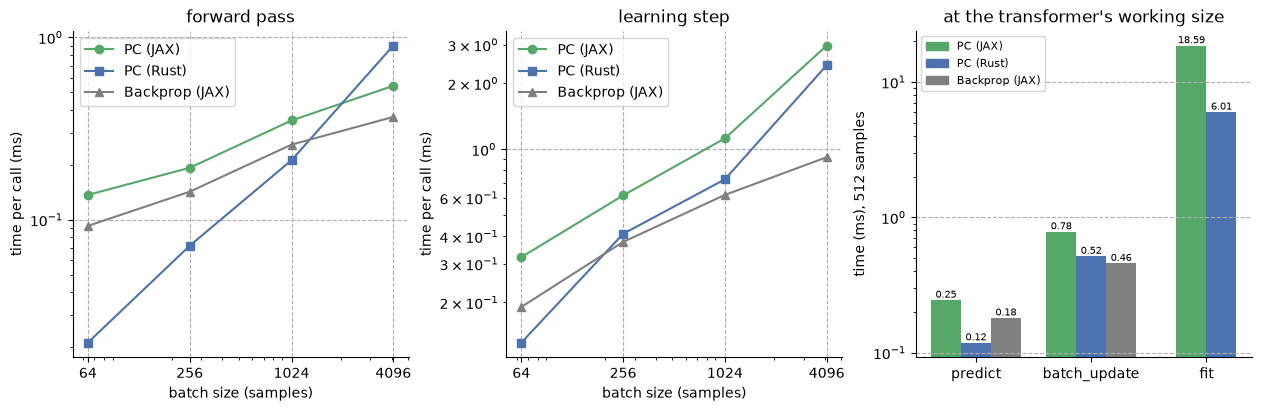

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12.5, 4))

for ax, times, title in (
    (ax1, predict_times, "forward pass"),
    (ax2, update_times, "learning step"),
):
    for label, values in times.items():
        ax.plot(
            batch_sizes,
            np.array(values) * 1e3,
            marker=MARKERS[label],
            color=COLORS[label],
            label=label,
        )
    ax.set(
        xscale="log", yscale="log",
        xlabel="batch size (samples)", ylabel="time per call (ms)",
        title=title, xticks=batch_sizes, xticklabels=batch_sizes,
    )
    ax.grid(linestyle="--")
    ax.legend()

# Fixed working size: 512 rows, fit rescaled from 1024 samples.
at_512 = {
    "predict": {
        label: np.interp(512, batch_sizes, values) * 1e3
        for label, values in predict_times.items()
    },
    "batch_update": {
        label: np.interp(512, batch_sizes, values) * 1e3
        for label, values in update_times.items()
    },
    "fit": {
        PC_JAX: fit_jax * 512 / n_sequential * 1e3,
        PC_RUST: fit_rs * 512 / n_sequential * 1e3,
    },
}
width = 0.26
for i, (entry, values) in enumerate(at_512.items()):
    for j, (label, ms) in enumerate(values.items()):
        offset = (j - (len(values) - 1) / 2) * width
        bar = ax3.bar(i + offset, ms, width, color=COLORS[label])
        ax3.annotate(
            f"{ms:.2f}",
            (i + offset, ms),
            ha="center", va="bottom", fontsize=7,
        )
ax3.set(
    xticks=range(len(at_512)), xticklabels=list(at_512), yscale="log",
    ylabel="time (ms), 512 samples", title="at the transformer's working size",
)
ax3.grid(axis="y", linestyle="--")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS[label])
    for label in (PC_JAX, PC_RUST, BACKPROP)
]
ax3.legend(handles, (PC_JAX, PC_RUST, BACKPROP), fontsize=8)
sns.despine()


## 7. Memory

Measuring memory fairly across three learners needs more care than
measuring time. Python-level tracers (`tracemalloc`) are blind to XLA's C++
buffers and to the Rust allocations; sampling the resident set from a
watcher thread misses short-lived peaks; and measuring everything in one
process is unfair by construction, since the kernel's peak-memory counter is
monotone and whichever learner runs first contaminates the rest.

The protocol here avoids all three problems:

- **Isolation.** Each measurement runs an identical small harness in a fresh
  subprocess: import, build the model and data, one warm-up call (which pays
  any compilation), then the measured calls.
- **Kernel high-water marks, not samples.** The peak comes from
  `resource.getrusage`, the high-water mark the kernel maintains for the
  process, which by construction cannot miss a peak (macOS reports bytes,
  Linux kibibytes; the harness normalises).
- **Three readings per run.** The resident set after warm-up (the
  *baseline*: everything imported, compiled, and cached), the high-water
  mark just after warm-up, and the high-water mark after the measured calls.
  The difference between the last two is the *step increment*: the
  additional memory the measured steps forced beyond anything setup already
  reserved. A step increment of zero is a finding, not a failure: the steps
  ran entirely inside memory the runtime had already reserved and reuses.

Two honest caveats. First, the totals are dominated by the runtime each
process stands up, not by the algorithm: the learners that execute through
XLA hold the JAX runtime's compiled programs and caches in their resident
set, while the Rust process leaves that machinery untouched and starts from
a far smaller baseline. Second, allocators cache: memory freed after warm-up
can stay resident, so differences between resident readings can understate
what the steps touch. The step increment and the analytical cross-checks
below (XLA's own buffer plan for the compiled step, and the closed-form size
of the Rust engine's batched state) bracket the truth from both sides.


In [10]:
import json
import subprocess
import sys

RUNNER = r'''
import gc, json, resource, sys

backend, batch, n_calls = sys.argv[1], int(sys.argv[2]), int(sys.argv[3])


def high_water():
    ru = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return ru * 1024 if sys.platform.startswith("linux") else ru


import numpy as np

rng = np.random.default_rng(0)
x = rng.normal(size=(batch, 64)).astype("float32")
y = rng.normal(size=(batch, 64)).astype("float32")

if backend == "rust":
    from pyhgf.rshgf import DeepNetwork

    net = DeepNetwork()
    for size in (64, 128, 64):
        net.add_layer(size, volatility_parent=False)
    net.weight_initialisation("he", seed=42)

    def step():
        net.batch_update(x, y, optimizer="adam", learning_rate=1e-3)

elif backend == "jax":
    import jax
    import optax

    from pyhgf.model import DeepNetwork

    net = DeepNetwork()
    for size in (64, 128, 64):
        net.add_layer(size=size, volatility_parent=False)
    opt = optax.adam(1e-3)

    def step():
        jax.block_until_ready(net.batch_update(x, y, optimizer=opt).input_errors)

else:  # backprop
    import equinox as eqx
    import jax
    import jax.numpy as jnp
    import optax

    keys = jax.random.split(jax.random.key(0), 2)
    model = [eqx.nn.Linear(64, 128, key=keys[0]), eqx.nn.Linear(128, 64, key=keys[1])]

    def forward(model, xi):
        for linear in model:
            xi = linear(xi)
        return xi

    def loss(model, xb, yb):
        return ((jax.vmap(lambda xi: forward(model, xi))(xb) - yb) ** 2).mean()

    opt = optax.adam(1e-3)
    state = {"model": model, "opt": opt.init(eqx.filter(model, eqx.is_array))}

    @eqx.filter_jit
    def bp_step(model, opt_state, xb, yb):
        _, grads = eqx.filter_value_and_grad(loss)(model, xb, yb)
        updates, opt_state = opt.update(grads, opt_state)
        return eqx.apply_updates(model, updates), opt_state

    xj, yj = jnp.asarray(x), jnp.asarray(y)

    def step():
        state["model"], state["opt"] = bp_step(state["model"], state["opt"], xj, yj)
        jax.block_until_ready(eqx.filter(state["model"], eqx.is_array))


step()  # warm-up: pays any compilation
gc.collect()
import psutil

baseline = psutil.Process().memory_info().rss
setup_peak = high_water()
for _ in range(n_calls):
    step()
peak = high_water()
print(json.dumps({"baseline": baseline, "setup_peak": setup_peak, "peak": peak}))
'''


def measure_memory(backend, batch, n_calls=5):
    """Baseline, setup peak, and total peak RSS of ``n_calls`` learning
    steps, measured in a fresh subprocess (bytes)."""
    result = subprocess.run(
        [sys.executable, "-c", RUNNER, backend, str(batch), str(n_calls)],
        capture_output=True, text=True, check=True,
    )
    return json.loads(result.stdout.strip().splitlines()[-1])


BACKENDS = {PC_JAX: "jax", PC_RUST: "rust", BACKPROP: "backprop"}
memory = {label: [measure_memory(b, batch) for batch in batch_sizes] for label, b in BACKENDS.items()}

MIB = 1024 * 1024
print(f"{'learner':>14} {'batch':>6} {'baseline':>10} {'step incr.':>11} {'total peak':>11}")
for label, runs in memory.items():
    for batch, run in zip(batch_sizes, runs):
        increment = (run["peak"] - run["setup_peak"]) / MIB
        print(
            f"{label:>14} {batch:>6} {run['baseline'] / MIB:>8.0f} MiB"
            f" {increment:>7.1f} MiB {run['peak'] / MIB:>7.0f} MiB"
        )

       learner  batch   baseline  step incr.  total peak
      PC (JAX)     64      316 MiB     0.0 MiB     318 MiB
      PC (JAX)    256      317 MiB     0.0 MiB     319 MiB
      PC (JAX)   1024      320 MiB     0.0 MiB     322 MiB
      PC (JAX)   4096      331 MiB     0.0 MiB     333 MiB
     PC (Rust)     64       70 MiB     0.0 MiB      71 MiB
     PC (Rust)    256       71 MiB     0.0 MiB      71 MiB
     PC (Rust)   1024       79 MiB     0.7 MiB      80 MiB
     PC (Rust)   4096      111 MiB    22.1 MiB     134 MiB
Backprop (JAX)     64      185 MiB     0.0 MiB     185 MiB
Backprop (JAX)    256      185 MiB     0.0 MiB     185 MiB
Backprop (JAX)   1024      187 MiB     0.0 MiB     187 MiB
Backprop (JAX)   4096      192 MiB     0.0 MiB     192 MiB


In [11]:
# Analytical cross-checks: XLA's buffer plan for the compiled predictive
# coding step, and the closed-form size of the Rust engine's batched state.
from pyhgf.utils.vectorized_belief_propagation import _batch_step

check_batch = batch_sizes[-1]
xb = rng.normal(size=(check_batch, 64)).astype("float32")
yb = rng.normal(size=(check_batch, 64)).astype("float32")
rs, jx = build_pair(SIZES)
optax_adam = optax.adam(1e-3)
jx.batch_update(xb, yb, optimizer=optax_adam)  # materialises the opt state
try:
    step_fn = jax.jit(
        lambda state, opt_state, xb, yb: _batch_step(
            state, opt_state, xb, yb,
            optimizer=optax_adam, learning_kind="precision_weighted",
            update_confidences=True, time_step=1.0,
        )
    )
    analysis = step_fn.lower(jx.state, jx.opt_state, xb, yb).compile().memory_analysis()
    print(
        f"XLA buffer plan, PC step at batch {check_batch}: "
        f"temporaries {analysis.temp_size_in_bytes / MIB:.1f} MiB, "
        f"arguments {analysis.argument_size_in_bytes / MIB:.1f} MiB, "
        f"output {analysis.output_size_in_bytes / MIB:.1f} MiB"
    )
except Exception as exc:  # noqa: BLE001 - the cross-check is informative only
    print(f"XLA memory analysis unavailable: {type(exc).__name__}")

# The Rust engine's batched state: seven value-level matrices per layer
# (mean, precision, expected mean, marginal / conditional predicted
# precision, effective precision, prediction error), each (n_nodes, batch)
# in float32, across the parallel slabs (whose widths sum to the batch).
state_bytes = 7 * sum(SIZES) * check_batch * 4
print(
    f"Rust batched state, closed form at batch {check_batch}: "
    f"{state_bytes / MIB:.1f} MiB (plus transients and the data copies)"
)

XLA buffer plan, PC step at batch 4096: temporaries 10.0 MiB, arguments 2.2 MiB, output 1.2 MiB
Rust batched state, closed form at batch 4096: 28.0 MiB (plus transients and the data copies)


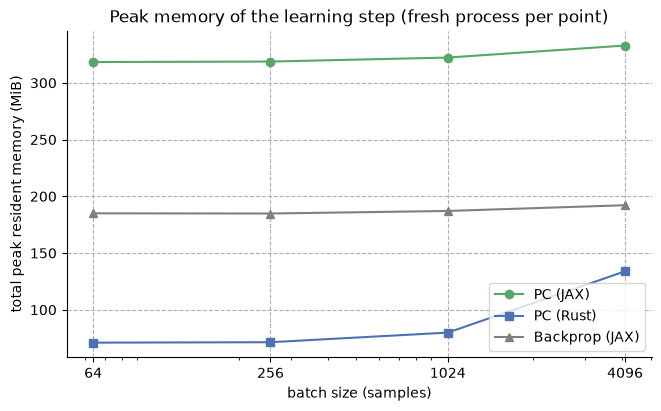

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for label, runs in memory.items():
    ax.plot(
        batch_sizes,
        [run["peak"] / MIB for run in runs],
        marker=MARKERS[label],
        color=COLORS[label],
        label=label,
    )
ax.set(
    xscale="log",
    xlabel="batch size (samples)", ylabel="total peak resident memory (MiB)",
    title="Peak memory of the learning step (fresh process per point)",
    xticks=batch_sizes, xticklabels=batch_sizes,
)
ax.grid(linestyle="--")
ax.legend()
sns.despine()


## 8. Reading the numbers

The measured ratios depend on the machine, the layer sizes, and the batch
size, so the figures above are the authoritative record for one machine;
what follows is the mechanism behind their shape.

- **The forward pass** is one matrix product per layer for all three
  learners. All calls are dominated by the same arithmetic at large
  batches; at small batches the fixed per-call overhead dominates instead
  (dispatching the compiled program on the JAX side, the Python boundary
  copies on the Rust side).
- **The learning step** separates the learners by what surrounds the matrix
  products. The two predictive coding learners run the same sweeps: XLA
  fuses the elementwise passes between the products into its one compiled
  program, while the Rust engine splits large batches into per-thread slabs
  of samples and sweeps each slab independently across CPU cores,
  recombining the per-slab means afterwards (samples are exchangeable, so
  the split changes nothing beyond floating point summation order). The
  backpropagation step is structurally lighter: one forward chain, one
  reverse chain, no belief state, which is why it sets the floor of the
  timing panel.
- **`fit`** is inherently sequential on both predictive coding backends
  (each sample's sweeps start from the beliefs the previous sample left
  behind); JAX rolls the loop into a compiled scan, the Rust engine into a
  native loop with no per-sample Python cost.
- **Compilation** is the structural difference on the JAX side: every entry
  point pays a one-off tracing and compilation cost per input shape
  (printed in section 4), which repeated calls amortise. The Rust engine
  pays nothing up front, which matters in workflows that change
  architectures or batch shapes more often than they reuse them.
- **Memory** separates into what the runtime holds and what the step
  touches, and the two order the learners differently. The total footprints
  follow the runtime: the Rust process stays smallest because executing it
  leaves the XLA machinery untouched, the backpropagation twin adds the
  compiled-program caches of one small jitted step, and the JAX predictive
  coding learner holds the largest compiled programs. The step's own demand
  moves the other way: the predictive coding state carries several belief
  and precision matrices per layer, batched over samples (the closed form
  printed above), where backpropagation stores weights, activations, and
  gradients only. On the JAX side XLA's buffer reuse absorbs that demand
  after warm-up, so the step increments sit near zero; the Rust engine
  allocates and frees its batched state on every call, so its increment
  grows with the batch while its total nevertheless stays the lowest at
  these model sizes.

Which backend to use, then? The Rust class covers the standalone network:
building, filtering, batch learning, all without touching the JAX runtime at
execution time. The JAX class is additionally a pytree, which is what the
mixed pipelines of the [transformer notebook](./0.8-Transformers.ipynb) rely
on to stage a whole model, learning parts and frozen calculations alike,
into one compiled training step; there is no Rust counterpart of that
pipeline machinery. The numerical parity shown in section 1 (and asserted
more broadly in `tests/test_rs_deepnetwork.py`) means results transfer
between backends whenever both cover the use case.
